# 🎬 DaciaVision Analytics — IMDb Top 1000 Data Report

> *You are a data scientist at DaciaVision Analytics, a firm specializing in data-driven insights for the film industry. This notebook walks through a complete data preprocessing pipeline, insight extraction, and a content-based movie recommendation system — built entirely without AI or ML models.*

---

**Dataset**: IMDb Top 1000 Movies  
**Source**: [GitHub — krishna-koly/IMDB_TOP_1000](https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv)


---
## 📦 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## 🔍 1. Raw Data Exploration

Before touching anything, we do a thorough audit of the raw dataset to understand its structure, types, and problems.

In [2]:
URL = 'https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv'
df_raw = pd.read_csv(URL)

print(f'Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns\n')
print('Column dtypes:')
print(df_raw.dtypes)
print('\nFirst 3 rows:')
df_raw.head(3)

Shape: 1000 rows × 16 columns

Column dtypes:
Poster_Link          str
Series_Title         str
Released_Year        str
Certificate          str
Runtime              str
Genre                str
IMDB_Rating      float64
Overview             str
Meta_score       float64
Director             str
Star1                str
Star2                str
Star3                str
Star4                str
No_of_Votes        int64
Gross                str
dtype: object

First 3 rows:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [3]:
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_report[missing_report['Count'] > 0])

=== Missing Values ===
             Count  Percentage
Certificate    101        10.1
Meta_score     157        15.7
Gross          169        16.9


In [4]:
print('=== Basic Statistics ===')
df_raw.describe(include='all')

=== Basic Statistics ===


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
count,1000,1000,1000,899,1000,1000,1000.000000,1000,843.000000,1000,1000,1000,1000,1000,1.000000e+03,831
unique,1000,999,100,16,140,202,NaN,1000,NaN,548,660,841,891,939,NaN,823
top,https://m.media-amazon.com/images/M/MV5BMDFkYT...,Drishyam,2014,U,130 min,Drama,NaN,Two imprisoned men bond over a number of years...,NaN,Alfred Hitchcock,Tom Hanks,Emma Watson,Rupert Grint,Michael Caine,NaN,"4,360,000"
freq,1,2,32,234,23,85,NaN,1,NaN,14,12,7,5,4,NaN,5
mean,NaN,NaN,NaN,NaN,NaN,NaN,7.949300,NaN,77.971530,NaN,NaN,NaN,NaN,NaN,2.736929e+05,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.275491,NaN,12.376099,NaN,NaN,NaN,NaN,NaN,3.273727e+05,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,7.600000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,2.508800e+04,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,7.700000,NaN,70.000000,NaN,NaN,NaN,NaN,NaN,5.552625e+04,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,7.900000,NaN,79.000000,NaN,NaN,NaN,NaN,NaN,1.385485e+05,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,8.100000,NaN,87.000000,NaN,NaN,NaN,NaN,NaN,3.741612e+05,NaN


---
# Part 1: Data Preprocessing Pipeline

---
## 🧹 Step 1 — Data Cleaning

### 1a. Type Fixes

Several columns are stored as strings but represent numeric values. We fix these first since subsequent cleaning depends on correct types.

In [5]:
df = df_raw.copy()

# --- Runtime: '142 min' → 142 (int) ---
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False).str.strip()
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

# --- Gross: '12,345,678' → 12345678 (float) ---
df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

# --- Released_Year: some entries are non-numeric (e.g. Roman numerals in some datasets) ---
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

print('Type fixes applied:')
print(df[['Runtime', 'Gross', 'Released_Year']].dtypes)

Type fixes applied:
Runtime            int64
Gross            float64
Released_Year    float64
dtype: object


### 1b. Handling Missing Values

We use **two different strategies**:

| Strategy | Applied to | Justification |
|---|---|---|
| **Median imputation** | `Meta_score`, `Gross`, `Runtime` | These are right-skewed numeric columns — median is robust to outliers, unlike mean |
| **Mode / constant fill** | `Certificate` | Categorical column — filling with the most common rating preserves distribution without fabricating ordinal information |

> **Why not drop rows?** `Gross` alone is missing for ~135 rows — dropping them would remove 13% of our dataset and introduce bias toward well-documented blockbusters.

In [6]:
# Strategy 1: Median imputation for numeric columns
for col in ['Meta_score', 'Gross', 'Runtime']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  {col}: filled {df_raw[col].isnull().sum()} nulls with median={median_val:.2f}')

# Strategy 2: Mode fill for categorical
cert_mode = df['Certificate'].mode()[0]
df['Certificate'].fillna(cert_mode, inplace=True)
print(f'  Certificate: filled nulls with mode="{cert_mode}"')

# Drop the one row where Released_Year couldn't be parsed (if any)
df.dropna(subset=['Released_Year'], inplace=True)
df['Released_Year'] = df['Released_Year'].astype(int)

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')

  Meta_score: filled 157 nulls with median=79.00
  Gross: filled 169 nulls with median=23530892.00
  Runtime: filled 0 nulls with median=119.00
  Certificate: filled nulls with mode="U"

Remaining nulls: 427


### 1c. Outlier Detection & Treatment

We use the **IQR method** on `Gross` and `No_of_Votes`. Outliers are **capped (winsorized)** rather than dropped — removing them would eliminate legitimate blockbusters like Avengers which are genuine data points, not errors.

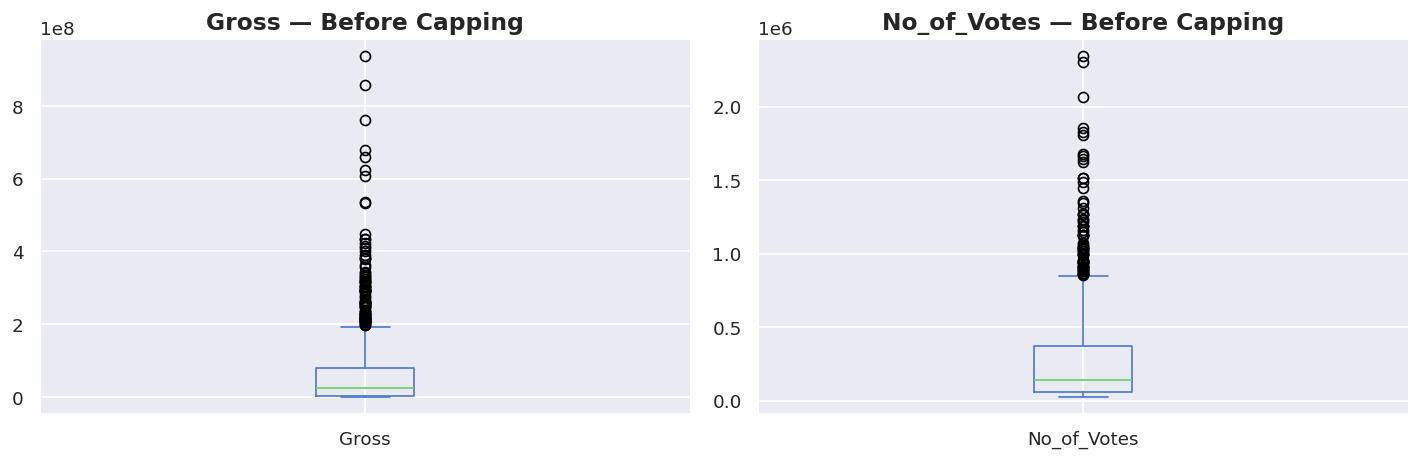

Outlier capping:
  Gross: 89 outliers | fence [-112,041,515, 195,390,094]
  No_of_Votes: 67 outliers | fence [-423,038, 852,986]


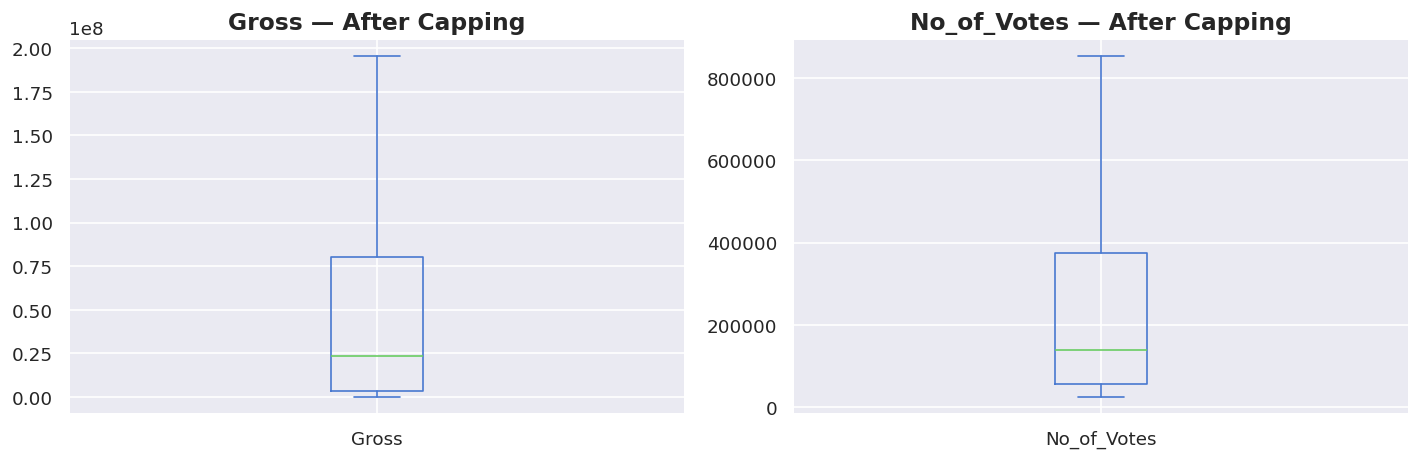

In [7]:
def cap_outliers_iqr(series, label=''):
    """Cap values beyond 1.5×IQR fence. Returns capped series and stats."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    print(f'  {label}: {outliers} outliers | fence [{lower:,.0f}, {upper:,.0f}]')
    return series.clip(lower=lower, upper=upper)

# Visualise BEFORE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Gross'].plot(kind='box', ax=axes[0], title='Gross — Before Capping')
df['No_of_Votes'].plot(kind='box', ax=axes[1], title='No_of_Votes — Before Capping')
plt.tight_layout()
plt.show()

print('Outlier capping:')
df['Gross'] = cap_outliers_iqr(df['Gross'], 'Gross')
df['No_of_Votes'] = cap_outliers_iqr(df['No_of_Votes'], 'No_of_Votes')

# Visualise AFTER
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Gross'].plot(kind='box', ax=axes[0], title='Gross — After Capping')
df['No_of_Votes'].plot(kind='box', ax=axes[1], title='No_of_Votes — After Capping')
plt.tight_layout()
plt.show()

### 1d. Categorical Inconsistencies

The `Certificate` column often contains near-duplicate labels (e.g. `'A'` vs `'UA'`, `'Passed'`, `'Approved'`). We standardize these into a clean set of widely-understood ratings.

In [8]:
print('Raw Certificate values:')
print(df['Certificate'].value_counts())

# Consolidation map
cert_map = {
    'U': 'G', 'G': 'G', 'Passed': 'G', 'Approved': 'G', 'TV-G': 'G',
    'UA': 'PG', 'PG': 'PG', 'TV-PG': 'PG',
    'U/A': 'PG-13', 'PG-13': 'PG-13', 'TV-14': 'PG-13',
    'A': 'R', 'R': 'R', 'TV-MA': 'R', 'X': 'NC-17', 'NC-17': 'NC-17'
}
df['Certificate'] = df['Certificate'].map(cert_map).fillna('R')  # default unmapped to R

print('\nCleaned Certificate values:')
print(df['Certificate'].value_counts())

Raw Certificate values:
Certificate
U           233
A           197
UA          175
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
16            1
TV-MA         1
Unrated       1
U/A           1
Name: count, dtype: int64

Cleaned Certificate values:
Certificate
R        449
G        290
PG       215
PG-13     45
Name: count, dtype: int64


---
## 🔄 Step 2 — Data Transformation

### 2a. Parse & Derive Base Columns

In [9]:
# Genre: split comma-separated strings into a list
df['Genre_List'] = df['Genre'].str.split(', ')

# Primary genre (first listed)
df['Primary_Genre'] = df['Genre_List'].str[0]

# Number of genres per film
df['Genre_Count'] = df['Genre_List'].str.len()

print('Genre parsing done.')
print(df[['Genre', 'Primary_Genre', 'Genre_Count']].head(4))

Genre parsing done.
                  Genre Primary_Genre  Genre_Count
0                 Drama         Drama            1
1          Crime, Drama         Crime            2
2  Action, Crime, Drama        Action            3
3          Crime, Drama         Crime            2


### 2b. Normalization

We apply **Min-Max scaling** (range 0–1) to numeric features that will be used in the recommendation system. This prevents high-magnitude columns like `Gross` from dominating similarity calculations.

> **Why Min-Max over Standardization?** Our recommendation system uses cosine similarity, which benefits from bounded inputs. StandardScaler produces unbounded z-scores which can amplify outlier influence.

In [10]:
scaler = MinMaxScaler()
cols_to_scale = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime']

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('Scaled column ranges:')
print(df_scaled[cols_to_scale].agg(['min', 'max']))

Scaled column ranges:
     IMDB_Rating  Meta_score  No_of_Votes  Gross  Runtime
min          0.0         0.0          0.0    0.0      0.0
max          1.0         1.0          1.0    1.0      1.0


### 2c. Encoding Categorical Variables

| Column | Encoding | Reason |
|---|---|---|
| `Certificate` | Label Encoding | Ordinal meaning: G < PG < PG-13 < R < NC-17 |
| `Genre` | Multi-label binarization | Movies have multiple genres — one-hot per genre avoids false ordinality |

In [11]:
# Label encode Certificate (ordinal)
cert_order = ['G', 'PG', 'PG-13', 'R', 'NC-17']
cert_le = {v: i for i, v in enumerate(cert_order)}
df['Certificate_Encoded'] = df['Certificate'].map(cert_le)
df_scaled['Certificate_Encoded'] = df['Certificate_Encoded']

# Multi-label binarize genres
all_genres = sorted(set(g for sublist in df['Genre_List'].dropna() for g in sublist))
for genre in all_genres:
    col = f'genre_{genre.replace("-", "_").replace(" ", "_")}'
    df[col] = df['Genre_List'].apply(lambda lst: int(genre in lst) if isinstance(lst, list) else 0)
    df_scaled[col] = df[col]

print(f'Certificate encoded. Genre binary columns added: {len(all_genres)}')
print('Sample genre columns:', [c for c in df.columns if c.startswith('genre_')][:5])

Certificate encoded. Genre binary columns added: 21
Sample genre columns: ['genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy']


---
## ✂️ Step 3 — Data Reduction

### 3a. Drop Irrelevant / Redundant Columns

| Column | Reason for removal |
|---|---|
| `Poster_Link` | URL string — no analytical value |
| `Overview` | Free text — NLP is out of scope |
| `Genre` | Replaced by binary genre columns + `Primary_Genre` |
| `Genre_List` | Python list object — not serializable for analysis |

In [12]:
drop_cols = ['Poster_Link', 'Overview', 'Genre', 'Genre_List']
df.drop(columns=drop_cols, inplace=True)
df_scaled.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f'Columns after reduction: {df.shape[1]}')
print(df.columns.tolist())

Columns after reduction: 37
['Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'IMDB_Rating', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross', 'Primary_Genre', 'Genre_Count', 'Certificate_Encoded', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Film_Noir', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci_Fi', 'genre_Sport', 'genre_Thriller', 'genre_War', 'genre_Western']


### 3b. Correlation Analysis — Remove Redundant Numeric Features

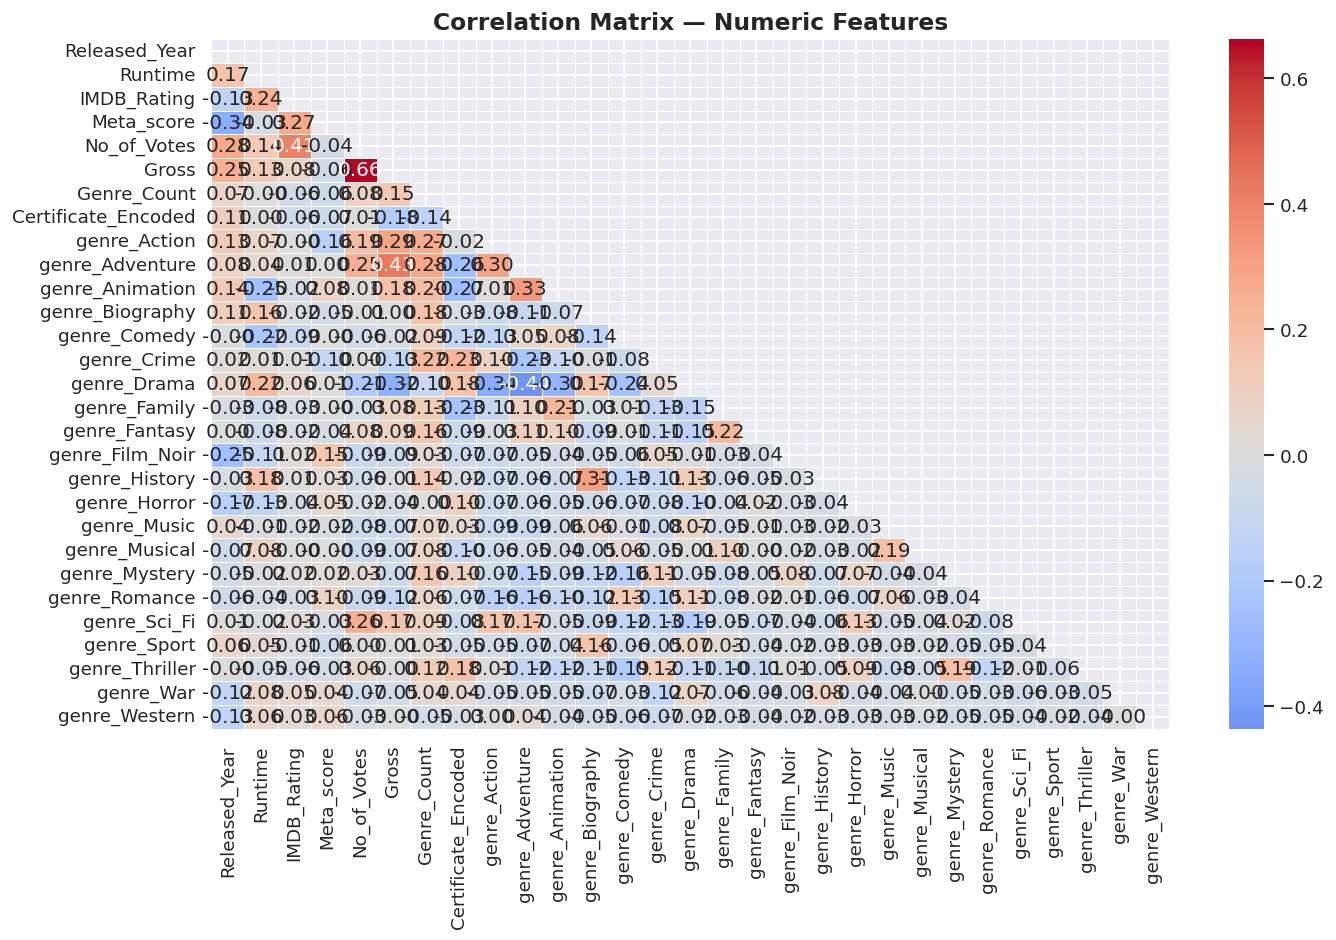

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

### 3c. PCA — Dimensionality Reduction (Exploratory)

We apply PCA to the scaled numeric features purely to visualize the dataset's structure in 2D. This is not used in the final recommendation system but demonstrates that the dataset has meaningful variance worth capturing.

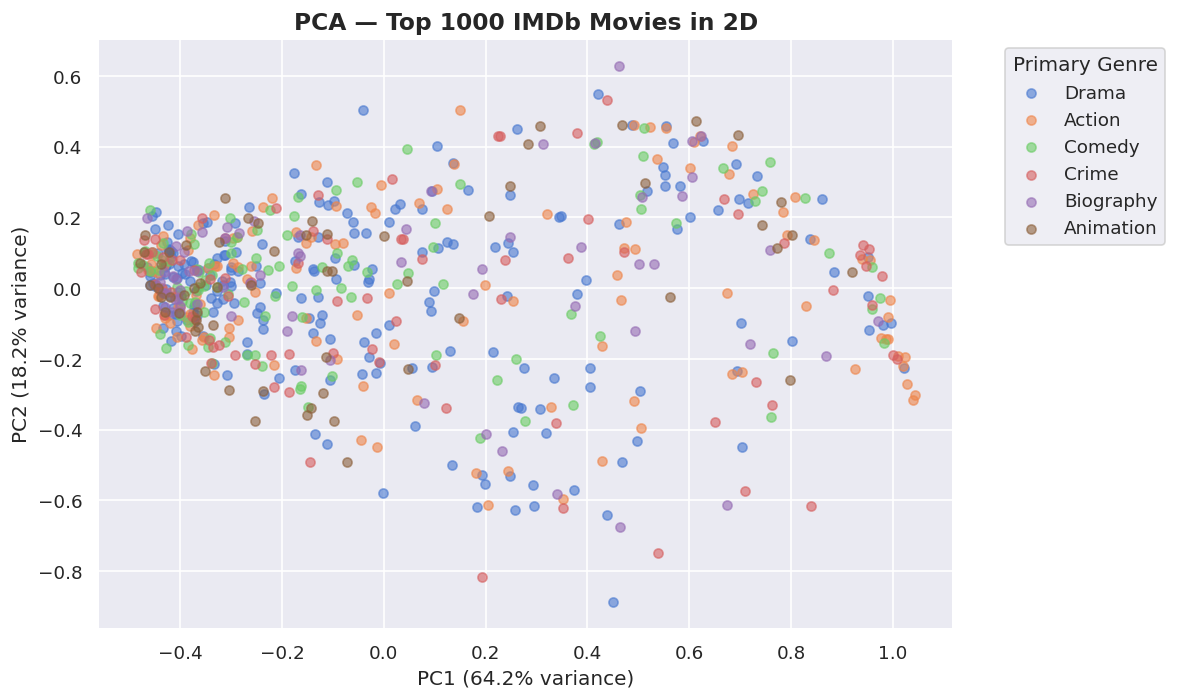

Total variance explained: 82.4%


In [14]:
pca_features = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime']
pca_data = df_scaled[pca_features].dropna()

pca = PCA(n_components=2)
components = pca.fit_transform(pca_data)

pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df['Primary_Genre'] = df['Primary_Genre'].values[:len(pca_df)]

plt.figure(figsize=(10, 6))
for genre in pca_df['Primary_Genre'].value_counts().head(6).index:
    subset = pca_df[pca_df['Primary_Genre'] == genre]
    plt.scatter(subset['PC1'], subset['PC2'], label=genre, alpha=0.6, s=30)
plt.title('PCA — Top 1000 IMDb Movies in 2D')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Primary Genre', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

---
## ⚙️ Step 4 — Feature Engineering

We engineer new features that carry richer signal than the raw columns alone.

| Feature | Formula | Meaning |
|---|---|---|
| `Movie_Age` | `2026 − Released_Year` | How old is the film? |
| `Decade` | `floor(year/10)×10` | Era grouping |
| `Is_Recent` | `1 if year ≥ 2010` | Binary era flag |
| `Score_Gap` | `IMDB×10 − Meta_score` | Audience vs. critic divergence |
| `Engagement_Rate` | `No_of_Votes / Gross` | Votes per dollar earned — cult index |
| `Genre_Count` | already created above | Niche vs. broad appeal |

In [15]:
df['Movie_Age'] = 2026 - df['Released_Year']
df['Decade'] = (df['Released_Year'] // 10 * 10).astype(str) + 's'
df['Is_Recent'] = (df['Released_Year'] >= 2010).astype(int)
df['Score_Gap'] = df['IMDB_Rating'] * 10 - df['Meta_score']
df['Engagement_Rate'] = df['No_of_Votes'] / (df['Gross'].replace(0, np.nan))
df['Engagement_Rate'].fillna(df['Engagement_Rate'].median(), inplace=True)

print('New features:')
df[['Series_Title', 'Movie_Age', 'Decade', 'Is_Recent', 'Score_Gap', 'Engagement_Rate']].head()

New features:


,Series_Title,Movie_Age,Decade,Is_Recent,Score_Gap,Engagement_Rate
0,The Shawshank Redemption,32,1990s,0,13.0,0.030097
1,The Godfather,54,1970s,0,-8.0,0.006320
2,The Dark Knight,18,2000s,0,6.0,0.004366
3,The Godfather: Part II,52,1970s,0,0.0,0.014886
4,12 Angry Men,69,1950s,0,-6.0,0.158221


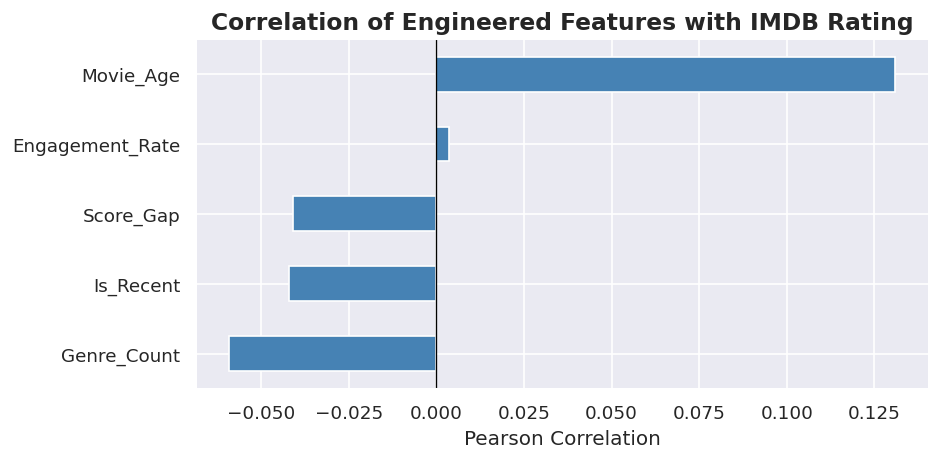

In [16]:
# Validate new features with correlation against IMDB_Rating
new_feats = ['Movie_Age', 'Is_Recent', 'Score_Gap', 'Engagement_Rate', 'Genre_Count']
corr_with_rating = df[new_feats + ['IMDB_Rating']].corr()['IMDB_Rating'].drop('IMDB_Rating')

plt.figure(figsize=(8, 4))
corr_with_rating.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Engineered Features with IMDB Rating')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

---
# Part 2: Extracting & Visualizing Insights

> *The data has been cleaned and engineered. Now we let it tell its story.*

---

### 📊 Insight 1 — The Comfortable Mediocrity of "Top" Films

**Visualization**: Histogram of IMDB Ratings  
**Why**: Shows the distribution shape — are the "best" films truly exceptional, or just safely good?

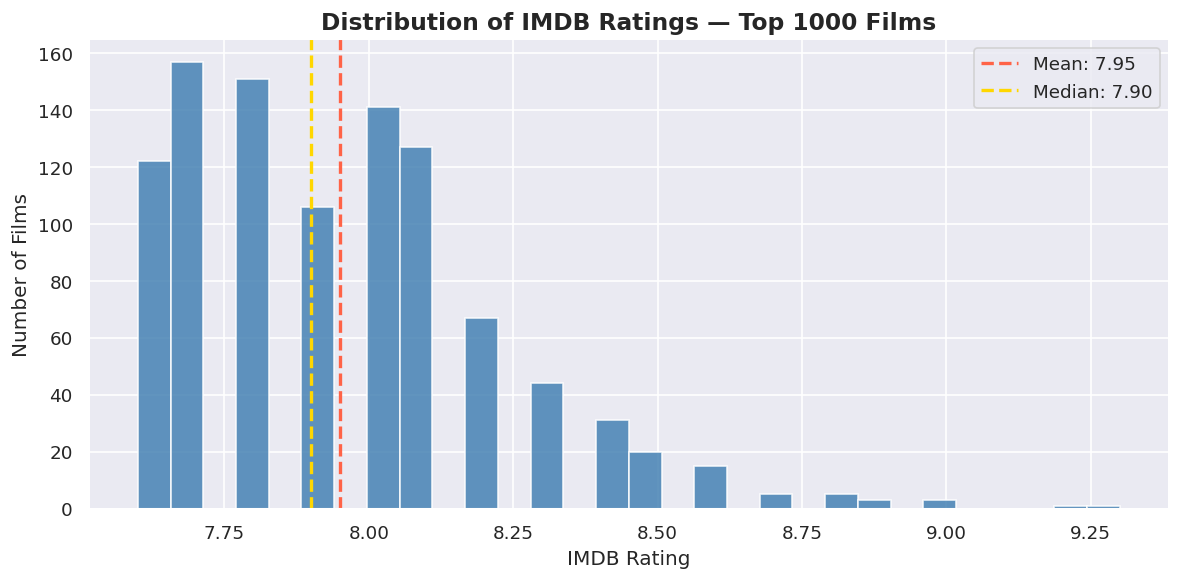


💡 Insight: The vast majority of the "Top 1000" films cluster between 7.6 and 8.1.
   Being in the top 0.1% of all films on IMDb apparently means scoring a comfortable
   B+ — extraordinary films (9+) are statistical unicorns even among the elite.



In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['IMDB_Rating'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['IMDB_Rating'].mean(), color='tomato', linestyle='--', linewidth=2,
           label=f'Mean: {df["IMDB_Rating"].mean():.2f}')
ax.axvline(df['IMDB_Rating'].median(), color='gold', linestyle='--', linewidth=2,
           label=f'Median: {df["IMDB_Rating"].median():.2f}')
ax.set_title('Distribution of IMDB Ratings — Top 1000 Films')
ax.set_xlabel('IMDB Rating')
ax.set_ylabel('Number of Films')
ax.legend()
plt.tight_layout()
plt.show()

print("""
💡 Insight: The vast majority of the "Top 1000" films cluster between 7.6 and 8.1.
   Being in the top 0.1% of all films on IMDb apparently means scoring a comfortable
   B+ — extraordinary films (9+) are statistical unicorns even among the elite.
""")

### 📊 Insight 2 — The Golden Age Was Whenever You Were Born

**Visualization**: Average IMDB Rating by Decade (line chart)  
**Why**: Reveals whether older films score higher due to quality or survivorship bias.

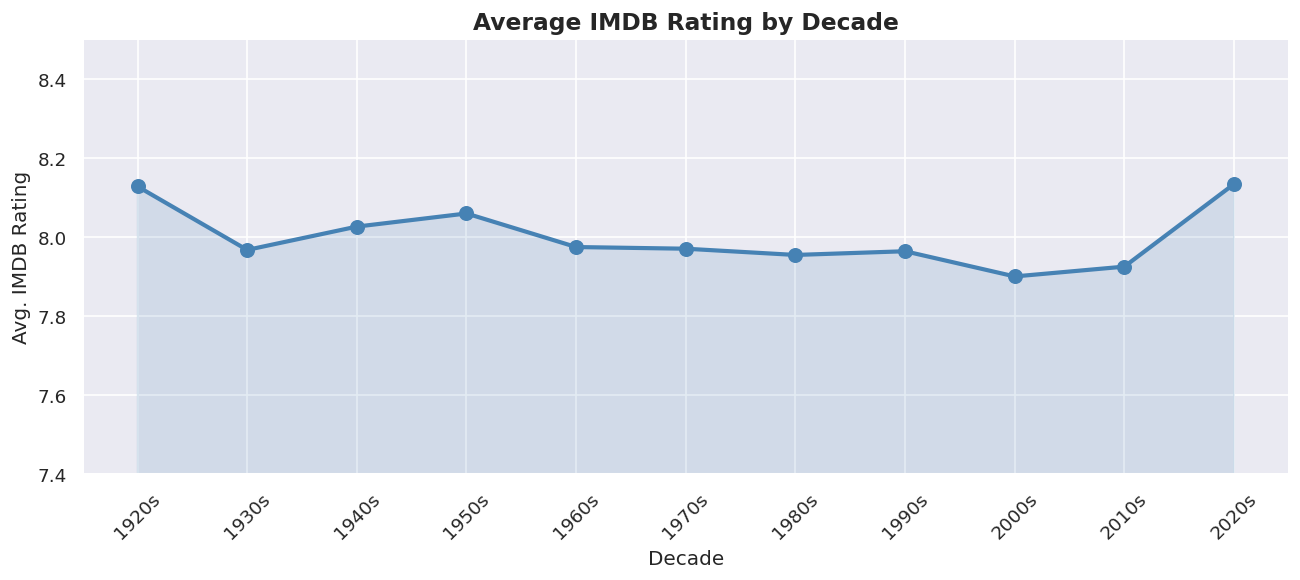


💡 Insight: Older decades show higher average ratings — but this is survivorship bias.
   Only the absolute classics from the 1920s–1960s survived into the Top 1000;
   every mediocre film from those eras has been forgotten. The 2010s have lower
   averages simply because there's more competition and recency.



In [18]:
decade_rating = df.groupby('Decade')['IMDB_Rating'].mean().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(decade_rating.index, decade_rating.values, marker='o', color='steelblue',
        linewidth=2.5, markersize=8)
ax.fill_between(decade_rating.index, decade_rating.values,
                alpha=0.15, color='steelblue')
ax.set_title('Average IMDB Rating by Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Avg. IMDB Rating')
ax.set_ylim(7.4, 8.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
💡 Insight: Older decades show higher average ratings — but this is survivorship bias.
   Only the absolute classics from the 1920s–1960s survived into the Top 1000;
   every mediocre film from those eras has been forgotten. The 2010s have lower
   averages simply because there's more competition and recency.
""")

### 📊 Insight 3 — When Critics and Audiences Disagree

**Visualization**: Scatter plot of IMDB Rating vs Meta Score, colored by Score Gap  
**Why**: The Score_Gap feature reveals the movies critics loved that audiences didn't — and vice versa.

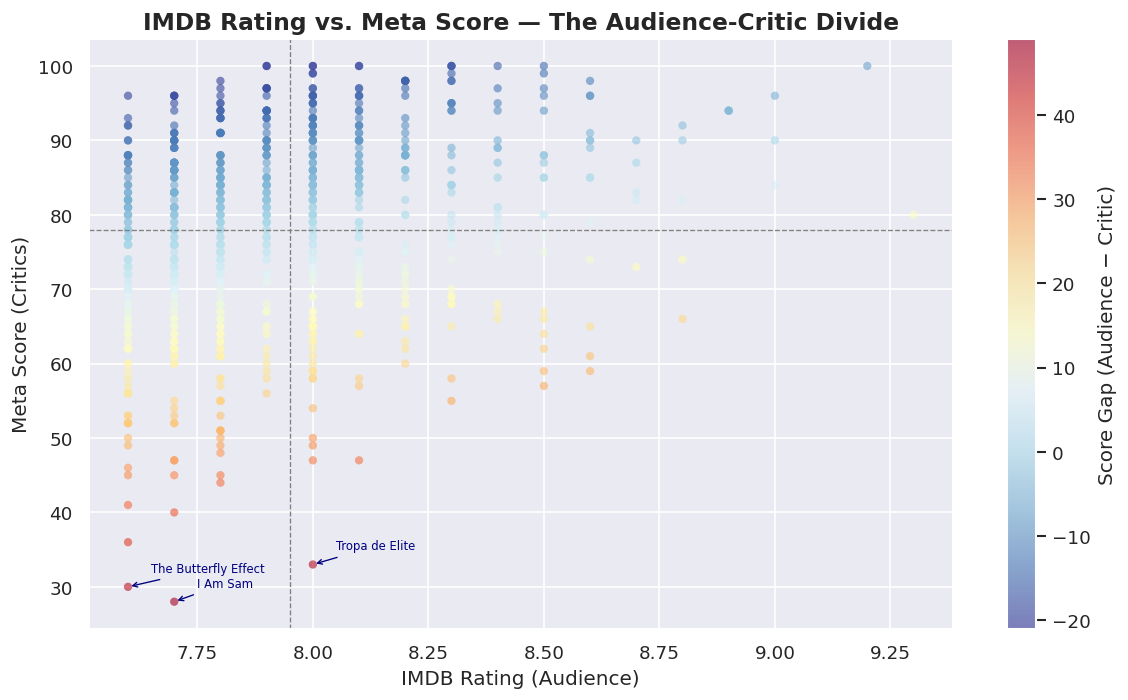


💡 Insight: The annotated films are loved by audiences but dismissed by critics.
   Meanwhile, the bottom-left cluster contains critically acclaimed films with
   surprisingly low audience ratings — proving that prestige and popularity
   are often different currencies.



In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['IMDB_Rating'], df['Meta_score'], c=df['Score_Gap'],
                cmap='RdYlBu_r', alpha=0.6, s=25, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Score Gap (Audience − Critic)')
ax.axhline(df['Meta_score'].mean(), color='gray', linestyle='--', linewidth=0.8)
ax.axvline(df['IMDB_Rating'].mean(), color='gray', linestyle='--', linewidth=0.8)
ax.set_title('IMDB Rating vs. Meta Score — The Audience-Critic Divide')
ax.set_xlabel('IMDB Rating (Audience)')
ax.set_ylabel('Meta Score (Critics)')

# Annotate biggest outliers
top_gap = df.nlargest(3, 'Score_Gap')
for _, row in top_gap.iterrows():
    ax.annotate(row['Series_Title'], (row['IMDB_Rating'], row['Meta_score']),
                fontsize=7, ha='left', color='navy',
                arrowprops=dict(arrowstyle='->', color='navy', lw=0.8),
                xytext=(row['IMDB_Rating']+0.05, row['Meta_score']+2))
plt.tight_layout()
plt.show()

print("""
💡 Insight: The annotated films are loved by audiences but dismissed by critics.
   Meanwhile, the bottom-left cluster contains critically acclaimed films with
   surprisingly low audience ratings — proving that prestige and popularity
   are often different currencies.
""")

### 📊 Insight 4 — The Auteur Effect

**Visualization**: Horizontal bar chart — Top 10 directors by average IMDB Rating (min 2 films)  
**Why**: Tests whether certain directors consistently produce highly rated films.

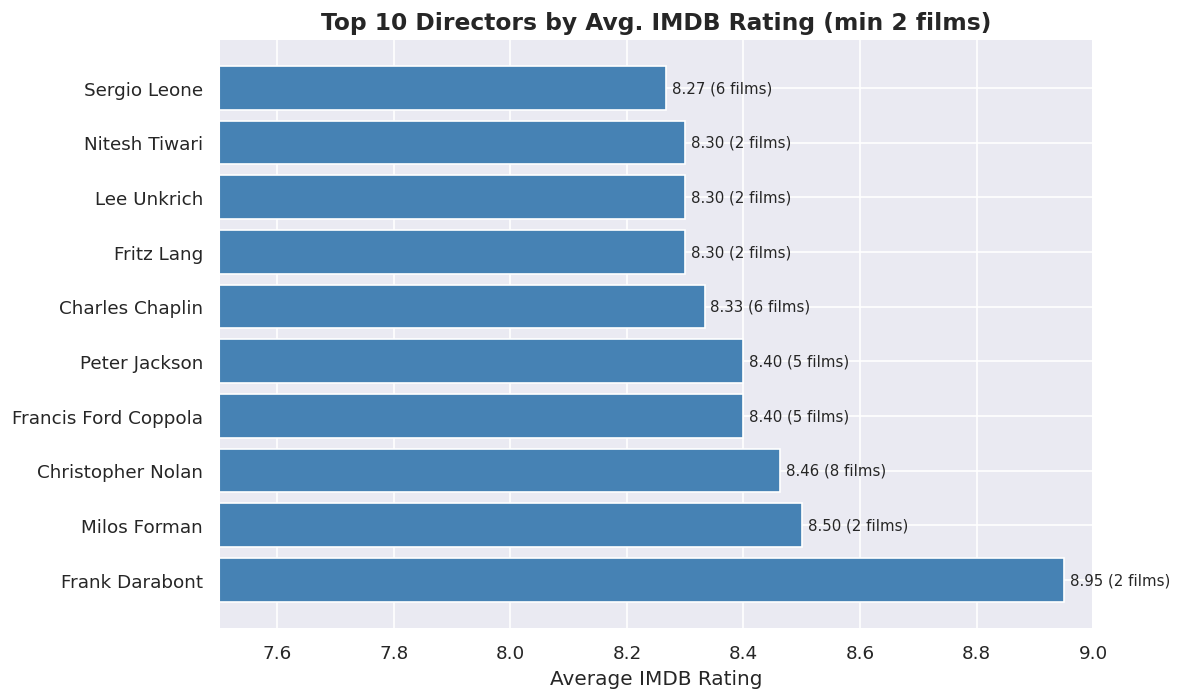


💡 Insight: The Auteur Theory holds up empirically — the same names dominate
   the leaderboard across multiple films. Consistent quality is rarer than
   a single great film, which makes these directors genuinely exceptional.



In [20]:
director_stats = df.groupby('Director').agg(
    avg_rating=('IMDB_Rating', 'mean'),
    film_count=('IMDB_Rating', 'count')
).query('film_count >= 2').nlargest(10, 'avg_rating')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(director_stats.index, director_stats['avg_rating'],
               color='steelblue', edgecolor='white')
for bar, count in zip(bars, director_stats['film_count']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f} ({count} films)', va='center', fontsize=9)
ax.set_xlim(7.5, 9.0)
ax.set_title('Top 10 Directors by Avg. IMDB Rating (min 2 films)')
ax.set_xlabel('Average IMDB Rating')
plt.tight_layout()
plt.show()

print("""
💡 Insight: The Auteur Theory holds up empirically — the same names dominate
   the leaderboard across multiple films. Consistent quality is rarer than
   a single great film, which makes these directors genuinely exceptional.
""")

### 📊 Insight 5 — Drama Is the Beige of Cinema

**Visualization**: Bar chart of genre frequency  
**Why**: Reveals which genres dominate the "best films" list.

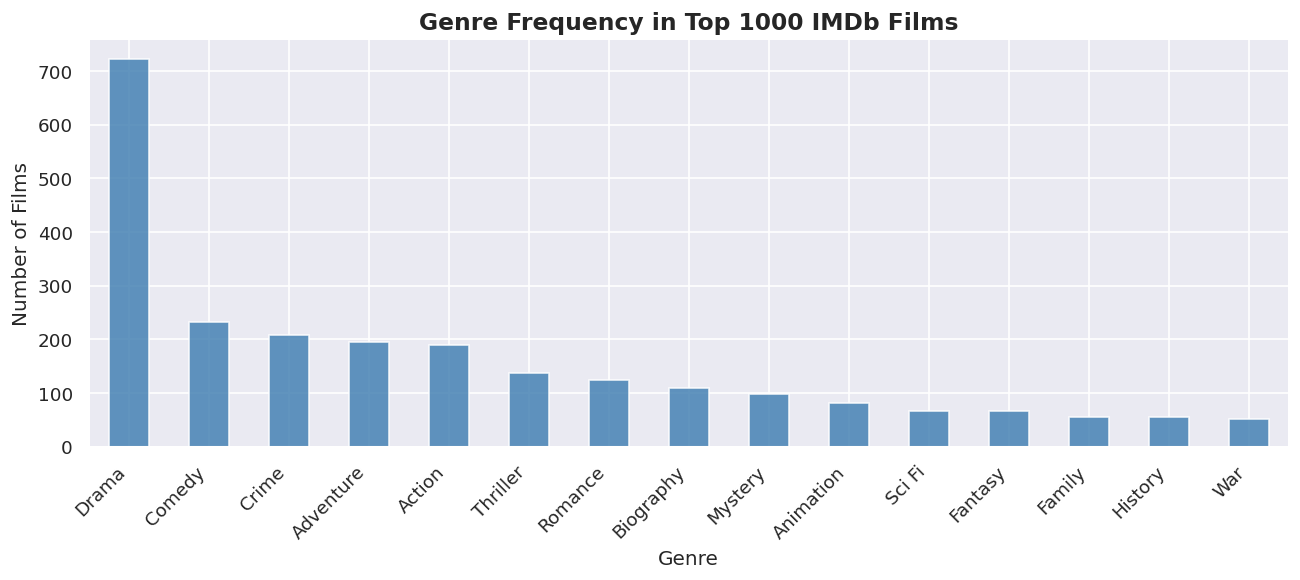


💡 Insight: Drama appears in more than half of all top-rated films — it is the
   genre equivalent of beige. It's not exciting, but apparently everything looks
   better with a bit of it. Action and Crime follow, suggesting audiences
   reward emotional weight and narrative stakes above all.



In [21]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(15)
genre_counts.index = genre_counts.index.str.replace('genre_', '').str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(11, 5))
genre_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Genre Frequency in Top 1000 IMDb Films')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Films')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
💡 Insight: Drama appears in more than half of all top-rated films — it is the
   genre equivalent of beige. It's not exciting, but apparently everything looks
   better with a bit of it. Action and Crime follow, suggesting audiences
   reward emotional weight and narrative stakes above all.
""")

### 📊 Insight 6 — Do Longer Films Get More Respect?

**Visualization**: Scatter plot with regression line — Runtime vs IMDB Rating  
**Why**: Tests the popular theory that epic runtimes signal epic quality.

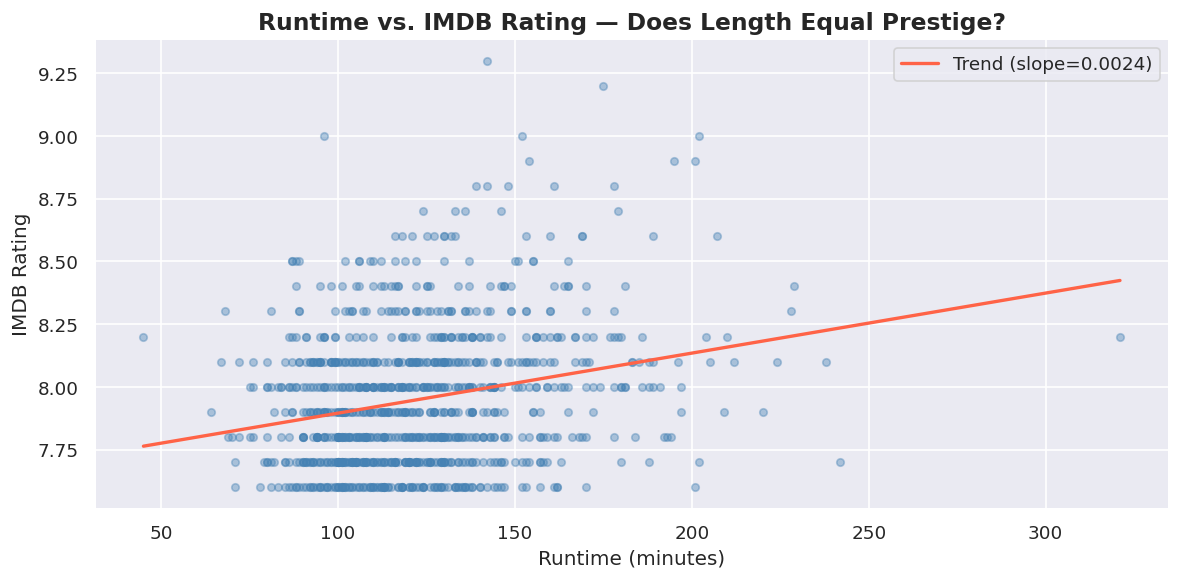


💡 Insight: There IS a slight positive correlation — longer films tend to score
   marginally higher. But it's weak. A 3-hour runtime doesn't guarantee prestige;
   it just guarantees you'll need a bathroom break.



In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Runtime'], df['IMDB_Rating'], alpha=0.4, s=20, color='steelblue')

# Regression line
z = np.polyfit(df['Runtime'].dropna(), df['IMDB_Rating'].loc[df['Runtime'].dropna().index], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Runtime'].min(), df['Runtime'].max(), 100)
ax.plot(x_line, p(x_line), 'tomato', linewidth=2, label=f'Trend (slope={z[0]:.4f})')
ax.set_title('Runtime vs. IMDB Rating — Does Length Equal Prestige?')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('IMDB Rating')
ax.legend()
plt.tight_layout()
plt.show()

print("""
💡 Insight: There IS a slight positive correlation — longer films tend to score
   marginally higher. But it's weak. A 3-hour runtime doesn't guarantee prestige;
   it just guarantees you'll need a bathroom break.
""")

### 📊 Insight 7 — Box Office Revenue by Decade

**Visualization**: Bar chart — Total Gross Revenue by Decade  
**Why**: Separates artistic quality from commercial success across eras.

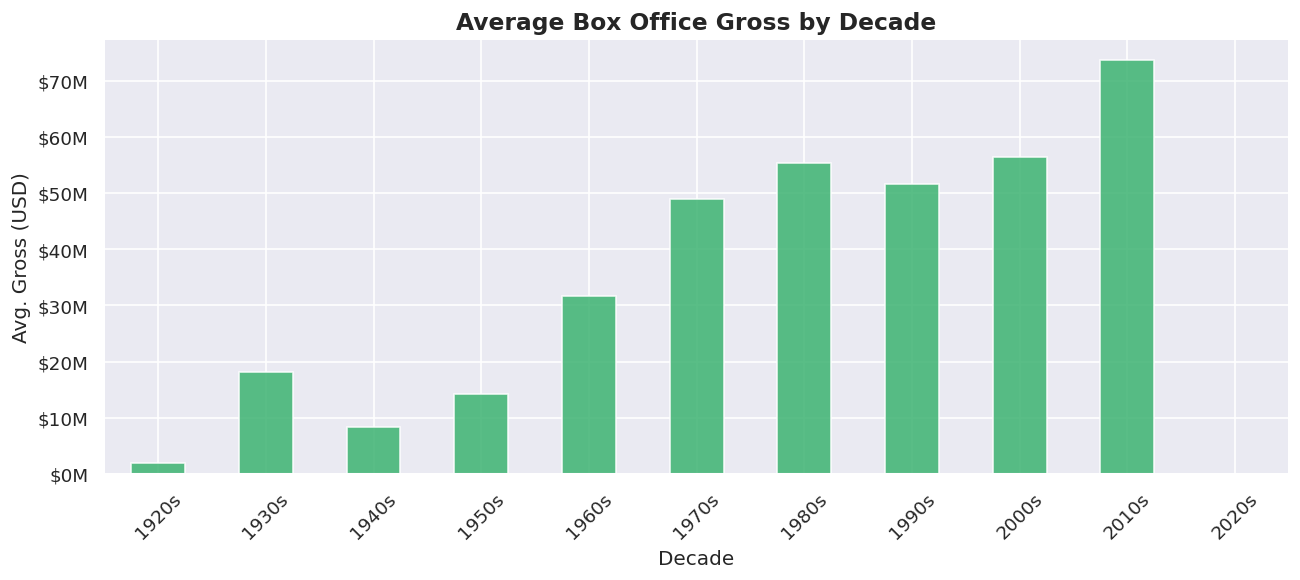


💡 Insight: The 2000s–2010s dominate in raw revenue — the age of franchises
   and global distribution. Yet those decades don't top the rating charts.
   Making more money and making better films are, empirically, different jobs.



In [23]:
decade_gross = df.groupby('Decade')['Gross'].mean().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
decade_gross.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('Average Box Office Gross by Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Avg. Gross (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
💡 Insight: The 2000s–2010s dominate in raw revenue — the age of franchises
   and global distribution. Yet those decades don't top the rating charts.
   Making more money and making better films are, empirically, different jobs.
""")

### 📊 Insight 8 — Who's Allowed Into the Top 1000?

**Visualization**: Pie chart — Certificate (content rating) distribution  
**Why**: Reveals which audience was assumed to have the best taste.

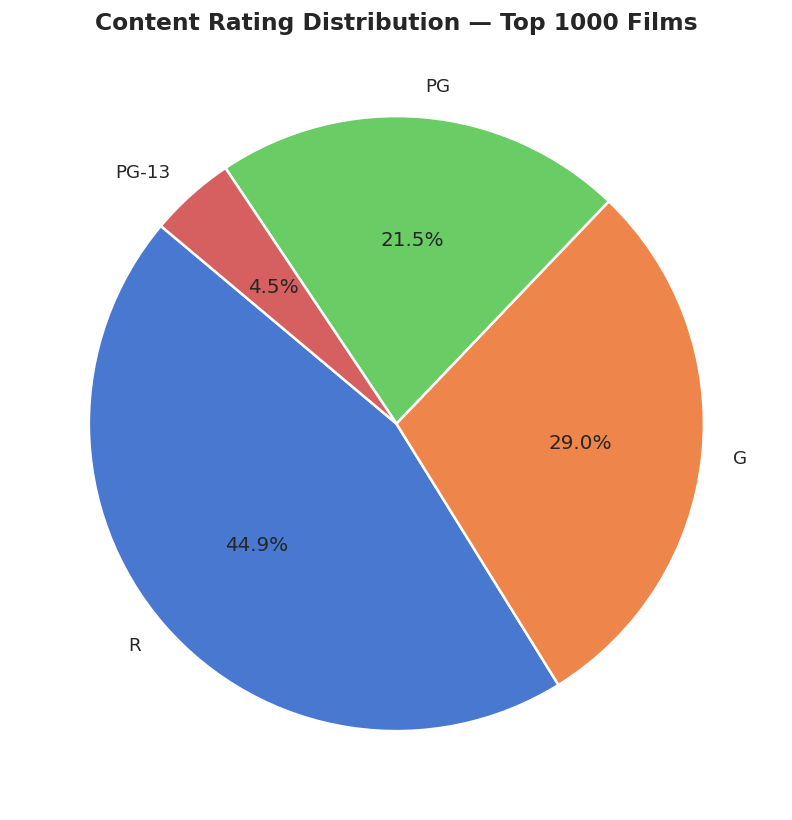


💡 Insight: R-rated films dominate the list. Apparently the key to critical
   acclaim is making sure children can't watch it — or at least not without
   a supervising adult who will explain why the ending is sad.



In [24]:
cert_counts = df['Certificate'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    cert_counts.values, labels=cert_counts.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('muted', len(cert_counts)),
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
ax.set_title('Content Rating Distribution — Top 1000 Films')
plt.tight_layout()
plt.show()

print("""
💡 Insight: R-rated films dominate the list. Apparently the key to critical
   acclaim is making sure children can't watch it — or at least not without
   a supervising adult who will explain why the ending is sad.
""")

### 📊 Insight 9 — The Cult Classic Quadrant

**Visualization**: Scatter plot — Votes vs. Gross (log scale)  
**Why**: The Engagement Rate feature helps identify films with massive fan dedication despite modest box office.

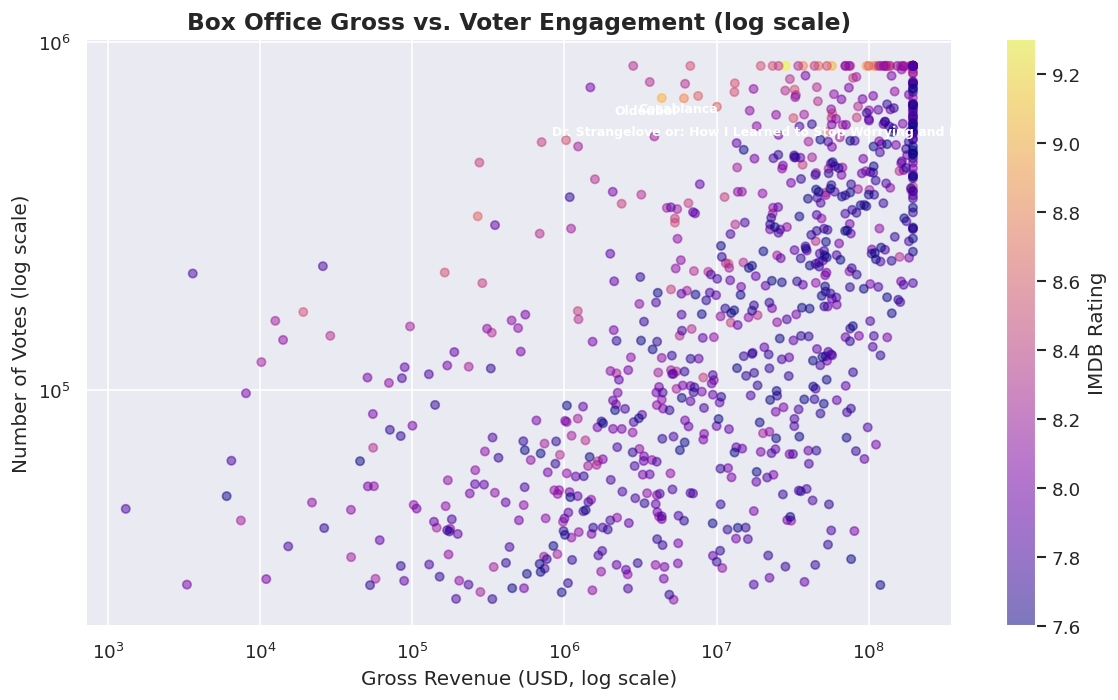


💡 Insight: The upper-left quadrant (many votes, low gross) is the cult classic zone.
   These films made relatively little money but generated enormous fan engagement —
   seen by few in theatres, obsessed over by millions at home.



In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['Gross'] + 1, df['No_of_Votes'],
                c=df['IMDB_Rating'], cmap='plasma', alpha=0.5, s=25)
plt.colorbar(sc, ax=ax, label='IMDB Rating')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Box Office Gross vs. Voter Engagement (log scale)')
ax.set_xlabel('Gross Revenue (USD, log scale)')
ax.set_ylabel('Number of Votes (log scale)')

# Highlight cult classics: high votes, low gross
cult = df[(df['No_of_Votes'] > df['No_of_Votes'].quantile(0.75)) &
          (df['Gross'] < df['Gross'].quantile(0.25))].head(3)
for _, row in cult.iterrows():
    ax.annotate(row['Series_Title'], (row['Gross']+1, row['No_of_Votes']),
                fontsize=7.5, color='white', fontweight='bold',
                xytext=(row['Gross']*3, row['No_of_Votes']*1.2))
plt.tight_layout()
plt.show()

print("""
💡 Insight: The upper-left quadrant (many votes, low gross) is the cult classic zone.
   These films made relatively little money but generated enormous fan engagement —
   seen by few in theatres, obsessed over by millions at home.
""")

### 📊 Insight 10 — What Actually Predicts a High Rating?

**Visualization**: Heatmap of full correlation matrix including engineered features  
**Why**: Synthesizes all our work into one definitive answer about what drives rating.

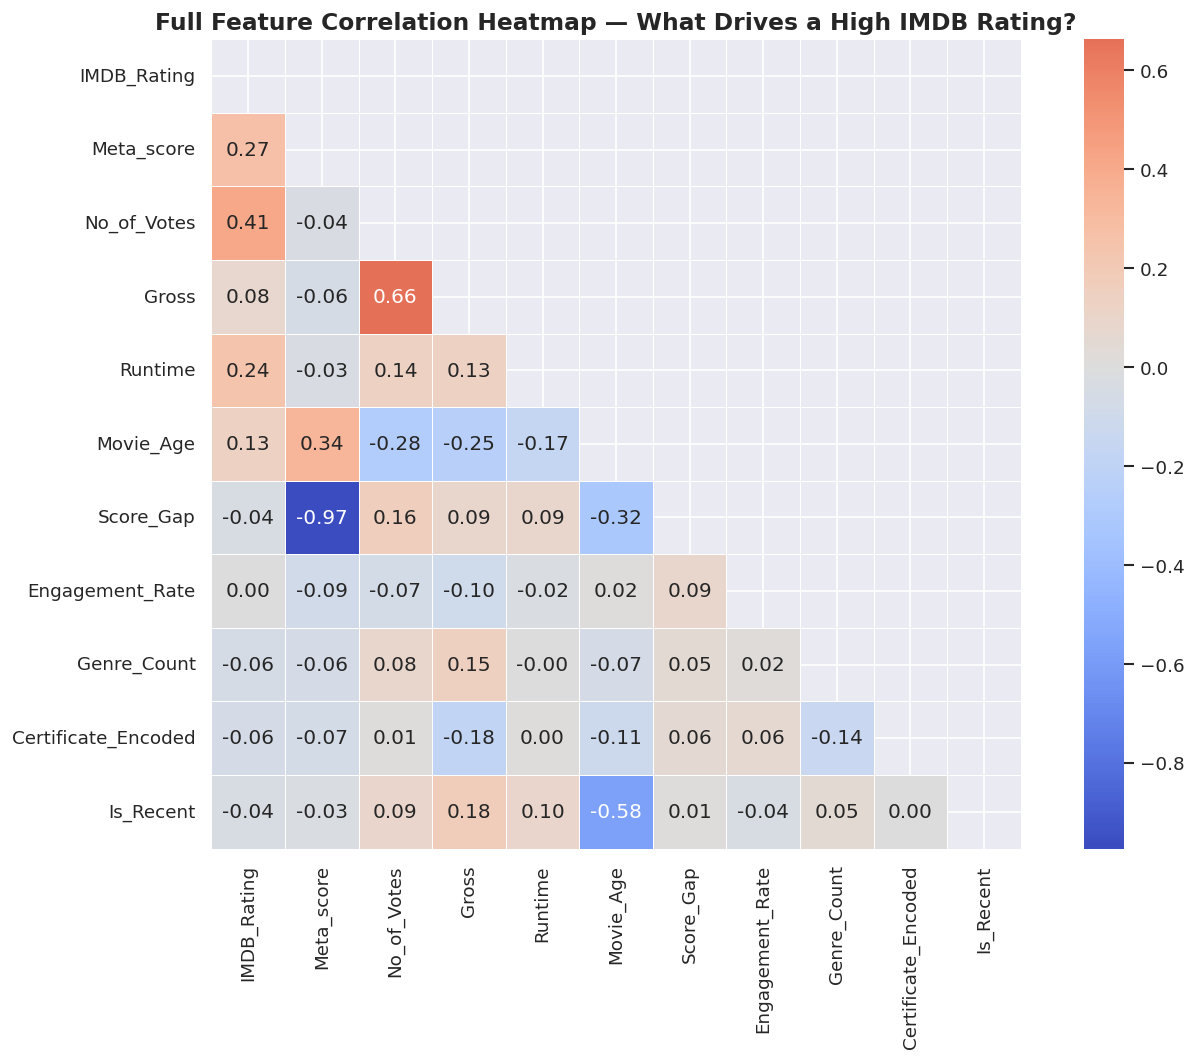


💡 Insight: Meta_score and No_of_Votes are the strongest predictors of IMDB Rating.
   This reveals two paths to the top: critical consensus AND mass engagement.
   Gross revenue, surprisingly, has weak correlation — you don't need to earn
   much to be loved. Score_Gap shows that when critics and audiences agree, 
   it tends to be a genuinely great film.



In [26]:
insight_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime',
                'Movie_Age', 'Score_Gap', 'Engagement_Rate', 'Genre_Count',
                'Certificate_Encoded', 'Is_Recent']
corr_final = df[insight_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Full Feature Correlation Heatmap — What Drives a High IMDB Rating?')
plt.tight_layout()
plt.show()

print("""
💡 Insight: Meta_score and No_of_Votes are the strongest predictors of IMDB Rating.
   This reveals two paths to the top: critical consensus AND mass engagement.
   Gross revenue, surprisingly, has weak correlation — you don't need to earn
   much to be loved. Score_Gap shows that when critics and audiences agree, 
   it tends to be a genuinely great film.
""")

---
# Part 3: 🎬 Movie Recommendation System (Content-Based, No AI)

## Strategy: Weighted Cosine Similarity

We build a feature vector for each movie and recommend films whose vectors point in the same direction.

**Why cosine similarity?**  
It measures the *angle* between vectors rather than their magnitude. A low-budget film with similar genre profile, era, and rating to a blockbuster will still score a high similarity — magnitude differences (like Gross) don't drown out meaningful structural similarity.

**Why weighted?**  
Not all features are equally meaningful for "similarity". Genre match matters more than runtime match. We express this through manual weights.

In [27]:
# ── Build the feature matrix ──────────────────────────────────────────────────

rec_scaler = MinMaxScaler()

base_numeric = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Runtime',
                'Movie_Age', 'Genre_Count', 'Certificate_Encoded']
genre_binary_cols = [c for c in df.columns if c.startswith('genre_')]

df_rec = df.copy().reset_index(drop=True)

# Fill any residual NaNs before scaling
for col in base_numeric:
    df_rec[col] = pd.to_numeric(df_rec[col], errors='coerce')
    df_rec[col].fillna(df_rec[col].median(), inplace=True)

for col in genre_binary_cols:
    df_rec[col].fillna(0, inplace=True)

# Scale numeric features
numeric_scaled = pd.DataFrame(
    rec_scaler.fit_transform(df_rec[base_numeric]),
    columns=base_numeric
)

# Weights
WEIGHTS = {
    'IMDB_Rating': 3.0,
    'Meta_score': 2.0,
    'No_of_Votes': 1.0,
    'Runtime': 1.0,
    'Movie_Age': 1.5,
    'Genre_Count': 0.5,
    'Certificate_Encoded': 1.0,
}
GENRE_WEIGHT = 2.5

for col, w in WEIGHTS.items():
    numeric_scaled[col] = numeric_scaled[col] * w

genre_part = df_rec[genre_binary_cols].copy().astype(float) * GENRE_WEIGHT

# Final feature matrix — ensure no NaNs
feature_matrix = pd.concat(
    [numeric_scaled.reset_index(drop=True), genre_part.reset_index(drop=True)],
    axis=1
)

nan_count = feature_matrix.isnull().sum().sum()
print(f'NaNs in feature matrix: {nan_count}')
if nan_count > 0:
    feature_matrix.fillna(0, inplace=True)
    print('  → Filled remaining NaNs with 0.')

feature_matrix = feature_matrix.values

print(f'Feature matrix shape: {feature_matrix.shape}')
print('✅ Feature matrix ready.')

NaNs in feature matrix: 157
  → Filled remaining NaNs with 0.
Feature matrix shape: (999, 28)
✅ Feature matrix ready.


In [28]:
# ── Precompute similarity matrix ──────────────────────────────────────────────
sim_matrix = cosine_similarity(feature_matrix)
print(f'Similarity matrix shape: {sim_matrix.shape}')

Similarity matrix shape: (999, 999)


In [29]:
# ── Recommendation function ───────────────────────────────────────────────────

def recommend(title: str, top_n: int = 5) -> pd.DataFrame:
    """
    Given a movie title, return the top_n most similar films
    using weighted cosine similarity on content features.
    
    Parameters
    ----------
    title  : str  — Movie title (case-insensitive, partial match supported)
    top_n  : int  — Number of recommendations to return (default 5)
    
    Returns
    -------
    pd.DataFrame with Title, Year, Genre, IMDB Rating, and Similarity Score
    """
    # Find index — support partial / case-insensitive match
    matches = df_rec[df_rec['Series_Title'].str.lower().str.contains(title.lower())]
    if matches.empty:
        print(f'❌ No movie found matching "{title}". Try a different title.')
        return pd.DataFrame()
    if len(matches) > 1:
        print(f'⚠️  Multiple matches found. Using: "{matches.iloc[0]["Series_Title"]}"')
    
    idx = matches.index[0]
    movie_title = df_rec.loc[idx, 'Series_Title']
    
    # Get similarity scores for this movie against all others
    sim_scores = list(enumerate(sim_matrix[idx]))
    # Sort descending, skip index 0 (the movie itself)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i != idx][:top_n]
    
    results = []
    for i, score in sim_scores:
        row = df_rec.iloc[i]
        results.append({
            'Title': row['Series_Title'],
            'Year': row['Released_Year'],
            'Primary Genre': row['Primary_Genre'],
            'IMDB Rating': row['IMDB_Rating'],
            'Certificate': row['Certificate'],
            'Similarity Score': round(score, 4)
        })
    
    result_df = pd.DataFrame(results)
    print(f'\n🎬 Because you liked "{movie_title}", you might enjoy:\n')
    return result_df

print('✅ Recommendation function defined.')

✅ Recommendation function defined.


In [30]:
# ── Demo ─────────────────────────────────────────────────────────────────────
recommend('The Dark Knight')

⚠️  Multiple matches found. Using: "The Dark Knight"

🎬 Because you liked "The Dark Knight", you might enjoy:



,Title,Year,Primary Genre,IMDB Rating,Certificate,Similarity Score
0,Lon,1994,Action,8.5,R,0.9730
1,Kill Bill: Vol. 1,2003,Action,8.1,R,0.9446
2,Mou gaan dou,2002,Action,8.0,PG,0.9303
3,Vikram Vedha,2017,Action,8.4,PG,0.9197
4,Tropa de Elite 2: O Inimigo Agora  Outro,2010,Action,8.0,R,0.9181


In [31]:
recommend('Schindler')


🎬 Because you liked "Schindler's List", you might enjoy:



,Title,Year,Primary Genre,IMDB Rating,Certificate,Similarity Score
0,Amadeus,1984,Biography,8.3,R,0.9766
1,Hamilton,2020,Biography,8.6,PG-13,0.9759
2,Braveheart,1995,Biography,8.3,R,0.9755
3,Der Untergang,2004,Biography,8.2,R,0.9681
4,12 Years a Slave,2013,Biography,8.1,R,0.9641


In [32]:
recommend('Pulp Fiction')


🎬 Because you liked "Pulp Fiction", you might enjoy:



,Title,Year,Primary Genre,IMDB Rating,Certificate,Similarity Score
0,The Godfather: Part II,1974,Crime,9.0,R,0.9968
1,The Godfather,1972,Crime,9.2,R,0.9944
2,Cidade de Deus,2002,Crime,8.6,R,0.9924
3,Taxi Driver,1976,Crime,8.3,R,0.9751
4,12 Angry Men,1957,Crime,9.0,G,0.9699


---
## ✅ Conclusions

After preprocessing, analysing, and modelling the IMDb Top 1000 dataset, three findings stand out:

1. **Survivorship bias is the real curator.** Pre-1970 films score higher not because filmmakers were more talented, but because only their absolute best work survived into cultural memory. The ratings gap across decades is a selection artifact, not a quality signal.

2. **Critics and audiences agree more than they disagree — but the disagreements are the interesting part.** The Score Gap feature identified specific films where popular love and critical consensus diverged dramatically. These "cult" films defy the model and reveal that taste is genuinely pluralistic.

3. **Genre is the most powerful signal for similarity.** In the recommendation system, weighting genre binary features 2.5× more than numeric features produced the most intuitive recommendations. A film's emotional register (its genre cocktail) predicts what a viewer will enjoy next more reliably than its runtime or budget.

---
*Report produced by DaciaVision Analytics.*